# Feature planned
- **clicks_week1/2/3**	         Total VLE clicks per week (weeks 1-3 only)	
- **click_trend**                Week 3 clicks minus Week 1 clicks
- **days_since_last_click**	     Days since last recorded activity
- **assessment_click_ratio**	 Proportion of clicks on quiz/assessment activity types
- **unique_resources**	         Number of distinct resources accessed
- **registered_late**	         Binary: registered after course start date	
- **unregistered_early**	     Binary: unregistered before course end	
- **num_of_prev_attempts**	     Number of previous attempts at the module
- **imd_band_enc**	             Deprivation index — ordinal encoded 0-9	
- **education_enc**	             Highest education level — ordinal encoded 0-4


# Procedure  Taken
- day 0 is the starting date(given)
- - Hence week 1 includes day 0
- Day of module end taken for each student depending on course from courses.csv
- Current date (for days since last click) taken as end date of respective module
- For missing Values taken days_since_last_click as days from start of module
- Left values that would imply the others (eg. gender_m true implies gender_f false, days_since_last_click high implies last_click_day small)

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
reg  = pd.read_csv('anonymisedData/studentRegistration.csv')
info = pd.read_csv('anonymisedData/studentInfo.csv')
vle  = pd.read_csv('anonymisedData/vle.csv')
svle = pd.read_csv('anonymisedData/studentVle.csv')

In [18]:
course = pd.read_csv('anonymisedData/courses.csv')

In [3]:
svle['week'] = (svle['date'] // 7)+1

In [11]:
a = svle[['week','date']]
a[a['date']==0]

,week,date
10847,1,0
10848,1,0
10849,1,0
10850,1,0
10851,1,0
...,...,...
10546559,1,0
10546560,1,0
10546561,1,0
10546562,1,0


In [12]:
for w in [1, 2, 3]:
    wk = (svle[svle['week'] == w].groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().rename(f'clicks_week{w}'))
    info = info.merge(wk, on=['id_student', 'code_module', 'code_presentation'], how='left')
    info[f'clicks_week{w}'] = info[f'clicks_week{w}'].fillna(0).astype(int)

In [16]:
info[['id_student','clicks_week1','clicks_week2','clicks_week3']]

,id_student,clicks_week1,clicks_week2,clicks_week3
0,11391,183,20,100
1,28400,175,66,37
2,30268,107,72,0
3,31604,22,154,108
4,32885,61,116,37
...,...,...,...,...
32588,2640965,1,16,22
32589,2645731,0,0,56
32590,2648187,9,0,0
32591,2679821,4,0,0


In [17]:
info['click_trend'] = info['clicks_week3'] - info['clicks_week1']

In [20]:
info=info.merge(course,  on=['code_module','code_presentation'], how='left')
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,183,20,100,-83,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,175,66,37,-138,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,107,72,0,-107,268
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,22,154,108,86,268
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,61,116,37,-24,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,1,16,22,21,269
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,0,0,56,56,269
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,9,0,0,-9,269
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,4,0,0,-4,269


In [22]:
last_click = svle.groupby(['id_student', 'code_module', 'code_presentation'])['date'].max().rename('last_click_day')
info = info.merge(last_click, on=['id_student', 'code_module', 'code_presentation'], how='left')
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length,last_click_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,183,20,100,-83,268,253.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,175,66,37,-138,268,239.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,107,72,0,-107,268,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,22,154,108,86,268,264.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,61,116,37,-24,268,247.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,1,16,22,21,269,19.0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,0,0,56,56,269,247.0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,9,0,0,-9,269,227.0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,4,0,0,-4,269,100.0


In [23]:
info['days_since_last_click'] = info['module_presentation_length']-info['last_click_day']
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length,last_click_day,days_since_last_click
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,183,20,100,-83,268,253.0,15.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,175,66,37,-138,268,239.0,29.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,107,72,0,-107,268,12.0,256.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,22,154,108,86,268,264.0,4.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,61,116,37,-24,268,247.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,1,16,22,21,269,19.0,250.0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,0,0,56,56,269,247.0,22.0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,9,0,0,-9,269,227.0,42.0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,4,0,0,-4,269,100.0,169.0


In [24]:
info['days_since_last_click'].describe()

count    29228.000000
mean        78.839880
std         89.832486
min          0.000000
25%          8.000000
50%         27.000000
75%        158.000000
max        292.000000
Name: days_since_last_click, dtype: float64

In [26]:
unique_res = svle.groupby(['id_student', 'code_module', 'code_presentation'])['id_site'].nunique().rename('unique_resources')
info = info.merge(unique_res, on=['id_student', 'code_module', 'code_presentation'], how='left')
info['unique_resources'] = info['unique_resources'].fillna(0).astype(int)
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length,last_click_day,days_since_last_click,unique_resources
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,183,20,100,-83,268,253.0,15.0,55
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,175,66,37,-138,268,239.0,29.0,84
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,107,72,0,-107,268,12.0,256.0,22
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,22,154,108,86,268,264.0,4.0,82
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,61,116,37,-24,268,247.0,21.0,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,1,16,22,21,269,19.0,250.0,8
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,0,0,56,56,269,247.0,22.0,50
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,9,0,0,-9,269,227.0,42.0,28
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,4,0,0,-4,269,100.0,169.0,17


In [28]:
#Need to figure out what is considered assessment
#total_clicks  = svle.groupby(KEY)['sum_click'].sum().rename('total_clicks')

,code_module,code_presentation,id_student,id_site,date,sum_click,week
0,AAA,2013J,28400,546652,-10,4,-1
1,AAA,2013J,28400,546652,-10,1,-1
2,AAA,2013J,28400,546652,-10,1,-1
3,AAA,2013J,28400,546614,-10,11,-1
4,AAA,2013J,28400,546714,-10,1,-1


In [29]:
info[['clicks_week1','clicks_week2','clicks_week3','click_trend','days_since_last_click','unique_resources']].describe().round(3)

,clicks_week1,clicks_week2,clicks_week3,click_trend,days_since_last_click,unique_resources
count,32593.000,32593.000,32593.000,32593.00,29228.000,32593.000
mean,61.764,55.154,70.785,9.02,78.840,60.151
std,104.955,90.106,103.487,103.02,89.832,55.899
min,0.000,0.000,0.000,-4205.00,0.000,0.000
25%,0.000,0.000,0.000,-20.00,8.000,19.000
50%,24.000,20.000,31.000,0.00,27.000,46.000
75%,81.000,72.000,102.000,39.00,158.000,86.000
max,4385.000,1566.000,1709.000,1454.00,292.000,413.000


In [31]:
info['days_since_last_click']=info['days_since_last_click'].fillna(info['module_presentation_length']).astype(int)

In [32]:
info[['clicks_week1','clicks_week2','clicks_week3','click_trend','days_since_last_click','unique_resources']].describe().round(3)

,clicks_week1,clicks_week2,clicks_week3,click_trend,days_since_last_click,unique_resources
count,32593.000,32593.000,32593.000,32593.00,32593.000,32593.000
mean,61.764,55.154,70.785,9.02,97.020,60.151
std,104.955,90.106,103.487,103.02,100.631,55.899
min,0.000,0.000,0.000,-4205.00,0.000,0.000
25%,0.000,0.000,0.000,-20.00,11.000,19.000
50%,24.000,20.000,31.000,0.00,34.000,46.000
75%,81.000,72.000,102.000,39.00,207.000,86.000
max,4385.000,1566.000,1709.000,1454.00,292.000,413.000


In [33]:
info = info.merge(reg,on=['id_student', 'code_module', 'code_presentation'], how='left')
info['registered_late'] = (info['date_registration'] > 0).astype(int)
info['unregistered_early'] = (
    info['date_unregistration'].notna() &
    (info['date_unregistration'] < info['module_presentation_length'])
).astype(int)

In [34]:
info


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,clicks_week3,click_trend,module_presentation_length,last_click_day,days_since_last_click,unique_resources,date_registration,date_unregistration,registered_late,unregistered_early
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,100,-83,268,253.0,15,55,-159.0,NaN,0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,37,-138,268,239.0,29,84,-53.0,NaN,0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0,-107,268,12.0,256,22,-92.0,12.0,0,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,108,86,268,264.0,4,82,-52.0,NaN,0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,37,-24,268,247.0,21,66,-176.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,22,21,269,19.0,250,8,-4.0,NaN,0,0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,56,56,269,247.0,22,50,-23.0,NaN,0,0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,0,-9,269,227.0,42,28,-129.0,NaN,0,0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,...,0,-4,269,100.0,169,17,-49.0,101.0,0,1


In [35]:

info.drop(columns=['date_registration', 'date_unregistration'], inplace=True)
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length,last_click_day,days_since_last_click,unique_resources,registered_late,unregistered_early
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,183,20,100,-83,268,253.0,15,55,0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,175,66,37,-138,268,239.0,29,84,0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,107,72,0,-107,268,12.0,256,22,0,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,22,154,108,86,268,264.0,4,82,0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,61,116,37,-24,268,247.0,21,66,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,1,16,22,21,269,19.0,250,8,0,0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,0,0,56,56,269,247.0,22,50,0,0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,9,0,0,-9,269,227.0,42,28,0,0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,...,4,0,0,-4,269,100.0,169,17,0,1


In [36]:
imdo = {'0-10%':0,'10-20':1,'20-30%':2,'30-40%':3,'40-50%':4,
             '50-60%':5,'60-70%':6,'70-80%':7,'80-90%':8,'90-100%':9}
info['imd_band_enc'] = info['imd_band'].map(imdo).fillna(4).astype(int)

eduo = {'No Formal quals': 0, 'Lower Than A Level': 1,
             'A Level or Equivalent': 2, 'HE Qualification': 3,
             'Post Graduate Qualification': 4}
info['education_enc'] = info['highest_education'].map(eduo)

In [37]:
info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,clicks_week3,click_trend,module_presentation_length,last_click_day,days_since_last_click,unique_resources,registered_late,unregistered_early,imd_band_enc,education_enc
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,100,-83,268,253.0,15,55,0,0,9,3
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,37,-138,268,239.0,29,84,0,0,2,3
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0,-107,268,12.0,256,22,0,1,3,2
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,108,86,268,264.0,4,82,0,0,5,2
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,37,-24,268,247.0,21,66,0,0,5,1


In [38]:
ageo = {'0-35':1,'35-55':2,'55<=':3}
info['age_enc'] = info['age_band'].map(ageo).astype(int)

In [41]:
reso = {'Pass': 0, 'Distinction': 0, 'Fail': 1, 'Withdrawn': 1}
info['at_risk'] = info['final_result'].map(reso)

In [42]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 32593 non-null  object 
 1   code_presentation           32593 non-null  object 
 2   id_student                  32593 non-null  int64  
 3   gender                      32593 non-null  object 
 4   region                      32593 non-null  object 
 5   highest_education           32593 non-null  object 
 6   imd_band                    31482 non-null  object 
 7   age_band                    32593 non-null  object 
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  object 
 11  final_result                32593 non-null  object 
 12  clicks_week1                32593 non-null  int32  
 13  clicks_week2                325

In [54]:
engineered= info[["gender","region","num_of_prev_attempts","studied_credits",
                  "disability","clicks_week1","clicks_week2","clicks_week3",
                  "click_trend","module_presentation_length","last_click_day",
                  "days_since_last_click","unique_resources","registered_late",
                  "unregistered_early","imd_band_enc","education_enc","age_enc",
                  "at_risk"]]

In [55]:
engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      32593 non-null  object 
 1   region                      32593 non-null  object 
 2   num_of_prev_attempts        32593 non-null  int64  
 3   studied_credits             32593 non-null  int64  
 4   disability                  32593 non-null  object 
 5   clicks_week1                32593 non-null  int32  
 6   clicks_week2                32593 non-null  int32  
 7   clicks_week3                32593 non-null  int32  
 8   click_trend                 32593 non-null  int32  
 9   module_presentation_length  32593 non-null  int64  
 10  last_click_day              29228 non-null  float64
 11  days_since_last_click       32593 non-null  int32  
 12  unique_resources            32593 non-null  int32  
 13  registered_late             325

In [56]:
e2 = pd.get_dummies(engineered,dtype=int)

In [57]:
e2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   num_of_prev_attempts         32593 non-null  int64  
 1   studied_credits              32593 non-null  int64  
 2   clicks_week1                 32593 non-null  int32  
 3   clicks_week2                 32593 non-null  int32  
 4   clicks_week3                 32593 non-null  int32  
 5   click_trend                  32593 non-null  int32  
 6   module_presentation_length   32593 non-null  int64  
 7   last_click_day               29228 non-null  float64
 8   days_since_last_click        32593 non-null  int32  
 9   unique_resources             32593 non-null  int32  
 10  registered_late              32593 non-null  int32  
 11  unregistered_early           32593 non-null  int32  
 12  imd_band_enc                 32593 non-null  int32  
 13  education_enc   

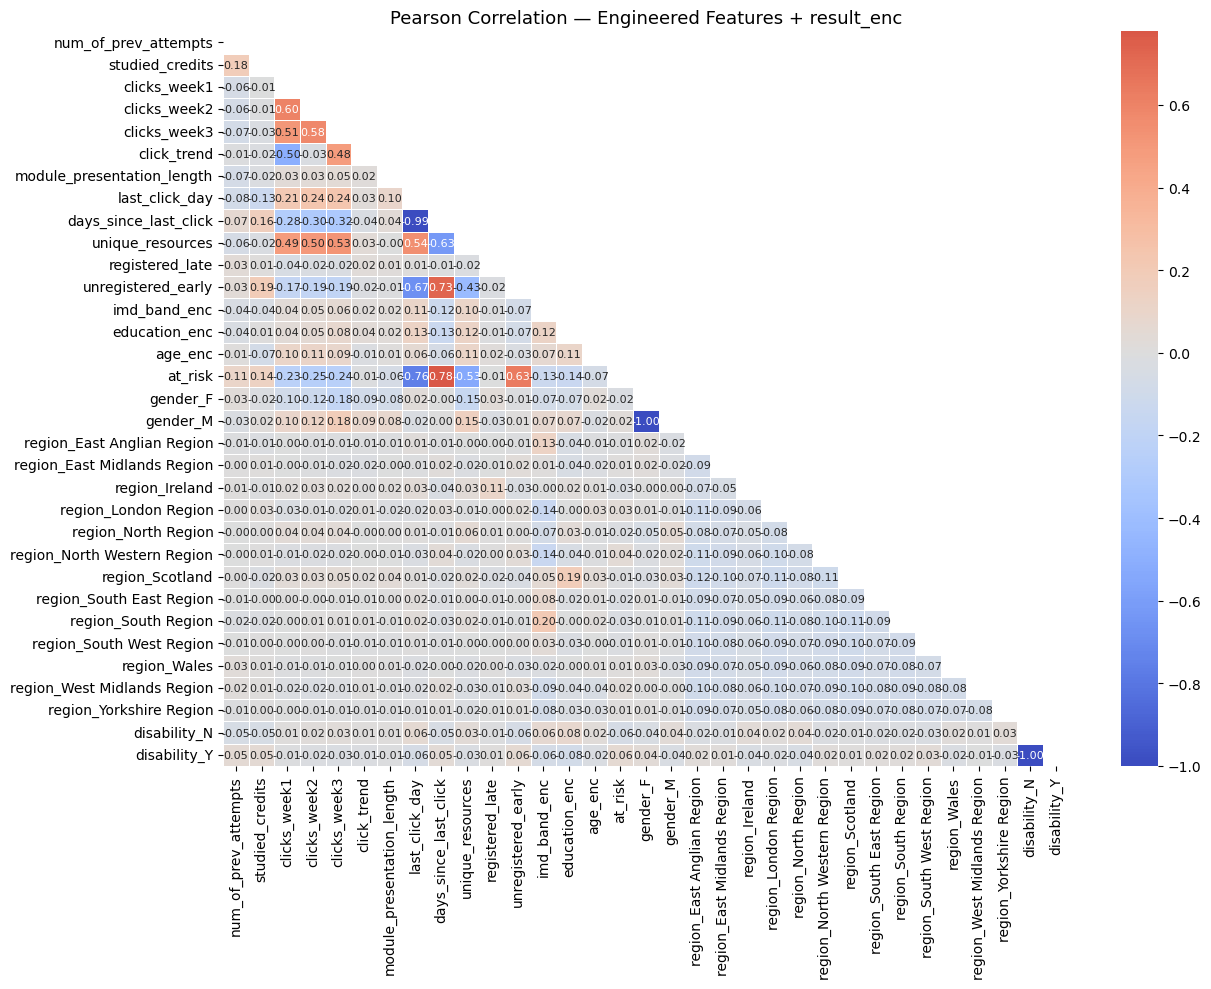

In [58]:
corr_df = e2.corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson Correlation — Engineered Features + result_enc', fontsize=13)
plt.tight_layout()
plt.show()

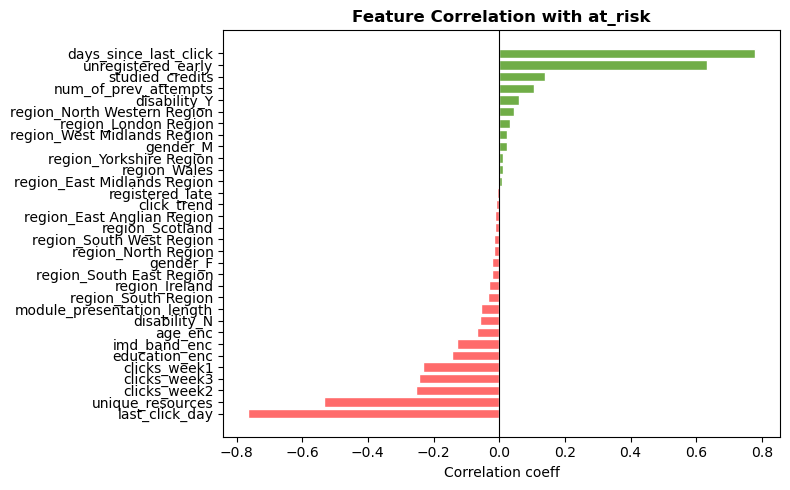


Correlation values:


,at_risk
last_click_day,-0.764
unique_resources,-0.533
clicks_week2,-0.254
clicks_week3,-0.243
clicks_week1,-0.232
education_enc,-0.144
imd_band_enc,-0.128
age_enc,-0.069
disability_N,-0.059
module_presentation_length,-0.056


In [60]:
target_corr = e2.corr()['at_risk'].drop('at_risk').sort_values()

colors = ['#FF6B6B' if v < 0 else '#70AD47' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with at_risk', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation coeff')
plt.tight_layout()
plt.show()

print('\nCorrelation values:')
display(target_corr.round(3).to_frame())